In [2]:
import pandas as pd
import numpy as np

In [3]:
movies = pd.read_csv('../data/imdb-top-1000.csv')

In [4]:
movies.head(10)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90.0
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4360000.0,96.0
5,The Lord of the Rings: The Return of the King,2003,201,Action,8.9,Peter Jackson,Elijah Wood,1642758,377845905.0,94.0
6,Pulp Fiction,1994,154,Crime,8.9,Quentin Tarantino,John Travolta,1826188,107928762.0,94.0
7,Schindler's List,1993,195,Biography,8.9,Steven Spielberg,Liam Neeson,1213505,96898818.0,94.0
8,Inception,2010,148,Action,8.8,Christopher Nolan,Leonardo DiCaprio,2067042,292576195.0,74.0
9,Fight Club,1999,139,Drama,8.8,David Fincher,Brad Pitt,1854740,37030102.0,66.0


In [5]:
# Group by is a method that allows you to group data based on one or more columns (used on categorical data/columns). It is often used in conjunction with aggregation functions to summarize data.

## syntax: dataframe.groupby('column_name')

## returs a GroupBy object that can be used to perform various operations on the grouped data.

## it lookes like a dictionary where the keys are the unique values in the specified column(s) and the values are the corresponding rows of data.

In [6]:
genres = movies.groupby('Genre')
genres

In [7]:
## Aggregation functions are used to summarize data in a groupby object. They can be applied to the grouped data to calculate various statistics such as sum, mean, min, max, count, etc.

# sum() → total
# mean() → average
# min() → smallest value
# max() → largest value
# count() → number of non-null values
# std() → standard deviation
# median() → median
# nunique() → number of unique values

In [8]:
# Applying builtin aggregation fuctions on groupby objects
# .std() is groupby object method that calculates the standard deviation of each group. It is used to measure the amount of variation or dispersion in a set of values. 

## .std() will tries to compute standard deviation for every column in each group so remove the non-numeric columns from the groupby object before applying the method.
## other wise it will throw an error as standard deviation is not defined for non-numeric data types.

genres[['Runtime', 'IMDB_Rating', 'No_of_Votes', 'Gross', 'Metascore']].std()

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,28.500706,0.304258,432946.814748,2.256724e+08,12.421252
Adventure,33.317320,0.229781,301188.347642,1.697543e+08,12.345393
Animation,14.530471,0.253221,262173.231571,2.091840e+08,8.813646
Biography,25.514466,0.267140,271284.191372,1.363251e+08,11.028187
Comedy,22.946213,0.228771,188653.570564,1.946513e+08,11.829160
Crime,27.689231,0.335477,373999.730656,1.571191e+08,13.099102
Drama,27.740490,0.267229,305554.162841,2.201164e+08,12.744687
Family,10.606602,0.000000,137008.302816,3.048412e+08,16.970563
Fantasy,12.727922,0.141421,22179.111299,7.606861e+07,NaN


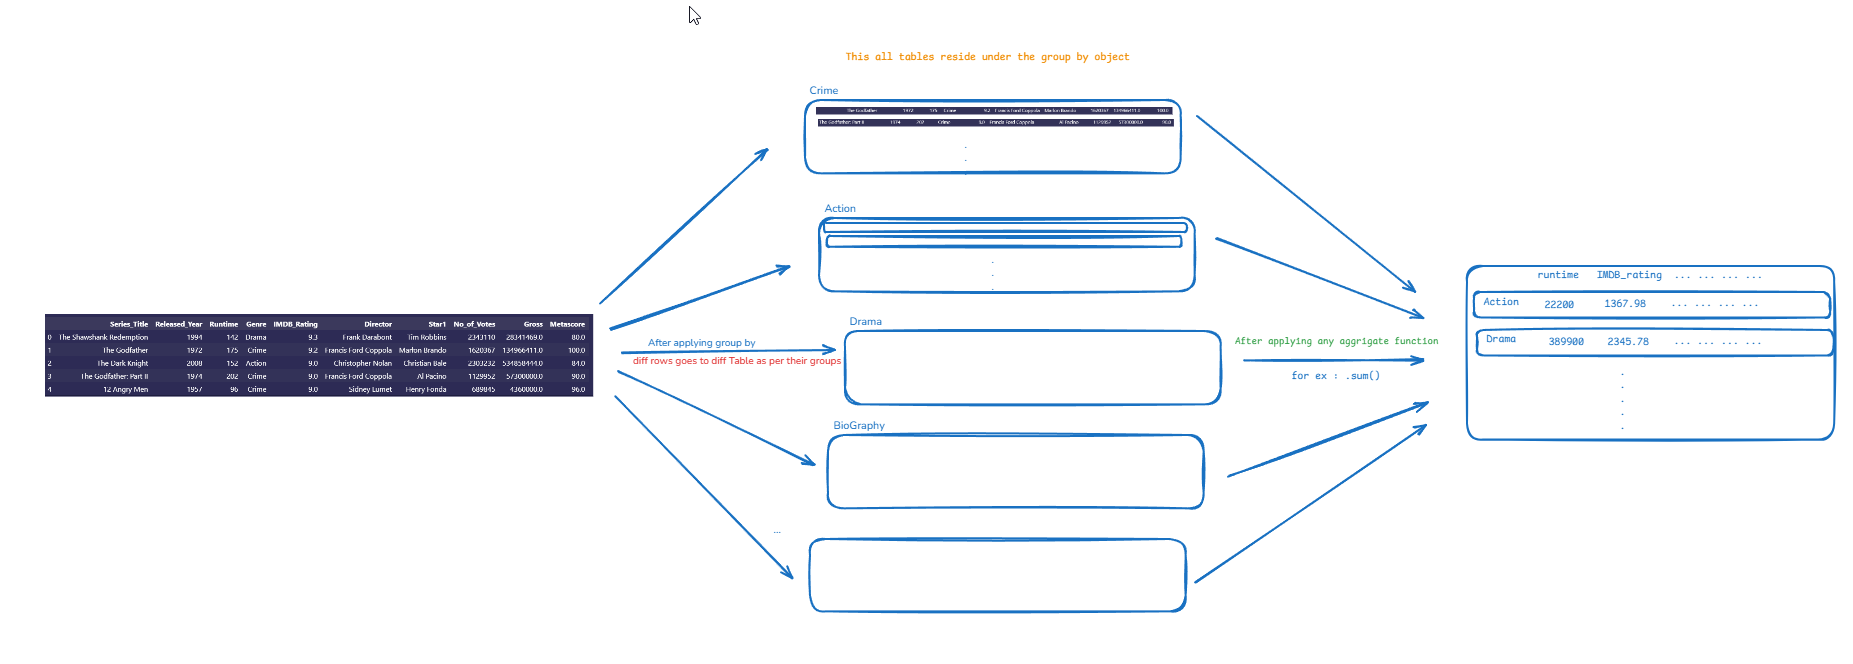

In [9]:
# find the top 3 genres by total earning
movies.groupby('Genre').sum()['Gross'].sort_values(ascending=False).head(3) 

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

In [10]:
movies.groupby('Genre')['Gross'].sum().sort_values(ascending=False).head(3)

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

In [11]:
## find std for on the column for runtime for each genre
# movies.groupby("Genre").std() -- will throw an error as std is not defined for non-numeric data types. So we will select only the numeric columns before applying the std method.

movies.groupby("Genre")['Runtime'].std()

Genre
Action       28.500706
Adventure    33.317320
Animation    14.530471
Biography    25.514466
Comedy       22.946213
Crime        27.689231
Drama        27.740490
Family       10.606602
Fantasy      12.727922
Film-Noir     4.000000
Horror       13.604812
Mystery      14.475423
Thriller           NaN
Western      17.153717
Name: Runtime, dtype: float64

In [12]:
# find the genre with highest avg IMDB rating
# movies.groupby('Genre')['IMDB_Rating'].mean()
movies.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False).head(1)

Genre
Western    8.35
Name: IMDB_Rating, dtype: float64

In [13]:
# find director with most popularity
movies.groupby('Director')['No_of_Votes'].sum().sort_values(ascending=False).head(1)

Director
Christopher Nolan    11578345
Name: No_of_Votes, dtype: int64

In [14]:
# find the highest IMDb rating of each genre
movies.groupby('Genre')['IMDB_Rating'].max()

Genre
Action       9.0
Adventure    8.6
Animation    8.6
Biography    8.9
Comedy       8.6
Crime        9.2
Drama        9.3
Family       7.8
Fantasy      8.1
Film-Noir    8.1
Horror       8.5
Mystery      8.4
Thriller     7.8
Western      8.8
Name: IMDB_Rating, dtype: float64

In [15]:
# find number of movies done by each actor
# movies['Star1'].value_counts()

movies.groupby('Star1')['Series_Title'].count().sort_values(ascending=False)

Star1
Tom Hanks             12
Robert De Niro        11
Clint Eastwood        10
Al Pacino             10
Leonardo DiCaprio      9
                      ..
Glen Hansard           1
Giuseppe Battiston     1
Giulietta Masina       1
Gerardo Taracena       1
Ömer Faruk Sorak       1
Name: Series_Title, Length: 660, dtype: int64

In [16]:
## agg = “apply one or more summary functions to grouped data”

genres["Runtime"].agg(['min', 'max', 'mean', 'sum']) # This applies multiple functions to each column for all columns.

,min,max,mean,sum
Genre,,,,
Action,45,321,129.046512,22196
Adventure,88,228,134.111111,9656
Animation,71,137,99.585366,8166
Biography,93,209,136.022727,11970
Comedy,68,188,112.129032,17380
Crime,80,229,126.392523,13524
Drama,64,242,124.737024,36049
Family,100,115,107.500000,215
Fantasy,76,94,85.000000,170


In [17]:
genres.agg({
    'Runtime': ['min', 'mean', 'max'],
    'Gross': 'sum',
    'IMDB_Rating': 'mean'
})  # This applies different functions to different explicit columns mentiond by us .

Runtime                          Gross IMDB_Rating
              min        mean  max           sum        mean
Genre                                                       
Action         45  129.046512  321  3.263226e+10    7.949419
Adventure      88  134.111111  228  9.496922e+09    7.937500
Animation      71   99.585366  137  1.463147e+10    7.930488
Biography      93  136.022727  209  8.276358e+09    7.938636
Comedy         68  112.129032  188  1.566387e+10    7.901290
Crime          80  126.392523  229  8.452632e+09    8.016822
Drama          64  124.737024  242  3.540997e+10    7.957439
Family        100  107.500000  115  4.391106e+08    7.800000
Fantasy        76   85.000000   94  7.827267e+08    8.000000
Film-Noir     100  104.000000  108  1.259105e+08    7.966667
Horror         71  102.090909  122  1.034649e+09    7.909091
Mystery        96  119.083333  138  1.256417e+09    7.975000
Thriller      108  108.000000  108  1.755074e+07    7.800000
Western       132  148.250000  165  5.822151e+07    8.350000

In [18]:
# GroupBy Attributes and Methods
# find total number of groups -> len
# find items in each group -> size
# first()/last() -> nth item
# get_group -> vs filtering
# groups
# describe
# sample
# nunique

In [19]:
len(movies.groupby('Genre'))   

14

In [20]:
movies['Genre'].nunique()  # same as above

14

In [21]:
movies.groupby('Genre').size()  ## returns a Series containing the size of each group. It counts the number of rows in each group and returns a Series with the group labels as the index and the corresponding group sizes as the values.

Genre
Action       172
Adventure     72
Animation     82
Biography     88
Comedy       155
Crime        107
Drama        289
Family         2
Fantasy        2
Film-Noir      3
Horror        11
Mystery       12
Thriller       1
Western        4
dtype: int64

In [22]:
genres = movies.groupby('Genre')
# genres.first()
# genres.last()
genres.nth(6)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
16,Star Wars: Episode V - The Empire Strikes Back,1980,124,Action,8.7,Irvin Kershner,Mark Hamill,1159315,290475067.0,82.0
27,Se7en,1995,127,Crime,8.6,David Fincher,Morgan Freeman,1445096,100125643.0,65.0
32,It's a Wonderful Life,1946,130,Drama,8.6,Frank Capra,James Stewart,405801,82385199.0,89.0
66,WALL·E,2008,98,Animation,8.4,Andrew Stanton,Ben Burtt,999790,223808164.0,95.0
83,The Great Dictator,1940,125,Comedy,8.4,Charles Chaplin,Charles Chaplin,203150,288475.0,NaN
102,Braveheart,1995,178,Biography,8.3,Mel Gibson,Mel Gibson,959181,75600000.0,68.0
118,North by Northwest,1959,136,Adventure,8.3,Alfred Hitchcock,Cary Grant,299198,13275000.0,98.0
420,Sleuth,1972,138,Mystery,8.0,Joseph L. Mankiewicz,Laurence Olivier,44748,4081254.0,NaN
724,Get Out,2017,104,Horror,7.7,Jordan Peele,Daniel Kaluuya,492851,176040665.0,85.0


In [23]:
movies['Genre'].value_counts()

Genre
Drama        289
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     72
Mystery       12
Horror        11
Western        4
Film-Noir      3
Fantasy        2
Family         2
Thriller       1
Name: count, dtype: int64

In [24]:
genres.get_group('Fantasy')  ## movies[movies['Genre'] == 'Fantasy']


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
321,Das Cabinet des Dr. Caligari,1920,76,Fantasy,8.1,Robert Wiene,Werner Krauss,57428,337574718.0,NaN
568,Nosferatu,1922,94,Fantasy,7.9,F.W. Murnau,Max Schreck,88794,445151978.0,NaN


In [25]:
genres.groups

{'Action': [2, 5, 8, 10, 13, 14, 16, 29, 30, 31, 39, 42, 44, 55, 57, 59, 60, 63, 68, 72, 106, 109, 129, 130, 134, 140, 142, 144, 152, 155, 160, 161, 166, 168, 171, 172, 177, 181, 194, 201, 202, 216, 217, 223, 224, 236, 241, 262, 275, 294, 308, 320, 325, 326, 331, 337, 339, 340, 343, 345, 348, 351, 353, 356, 357, 362, 368, 369, 375, 376, 390, 410, 431, 436, 473, 477, 479, 482, 488, 493, 496, 502, 507, 511, 532, 535, 540, 543, 564, 569, 570, 573, 577, 582, 583, 602, 605, 608, 615, 623, ...], 'Adventure': [21, 47, 93, 110, 114, 116, 118, 137, 178, 179, 191, 193, 209, 226, 231, 247, 267, 273, 281, 300, 301, 304, 306, 323, 329, 361, 366, 377, 402, 406, 415, 426, 458, 470, 497, 498, 506, 513, 514, 537, 549, 552, 553, 566, 576, 604, 609, 618, 638, 647, 675, 681, 686, 692, 711, 713, 739, 755, 781, 797, 798, 851, 873, 884, 912, 919, 947, 957, 964, 966, 984, 991], 'Animation': [23, 43, 46, 56, 58, 61, 66, 70, 101, 135, 146, 151, 158, 170, 197, 205, 211, 213, 219, 229, 230, 242, 245, 246, 270, 33

In [26]:
genres.describe()

Runtime                                                              \
            count        mean        std    min     25%    50%     75%    max   
Genre                                                                           
Action      172.0  129.046512  28.500706   45.0  110.75  127.5  143.25  321.0   
Adventure    72.0  134.111111  33.317320   88.0  109.00  127.0  149.00  228.0   
Animation    82.0   99.585366  14.530471   71.0   90.00   99.5  106.75  137.0   
Biography    88.0  136.022727  25.514466   93.0  120.00  129.0  146.25  209.0   
Comedy      155.0  112.129032  22.946213   68.0   96.00  106.0  124.50  188.0   
Crime       107.0  126.392523  27.689231   80.0  106.50  122.0  141.50  229.0   
Drama       289.0  124.737024  27.740490   64.0  105.00  121.0  137.00  242.0   
Family        2.0  107.500000  10.606602  100.0  103.75  107.5  111.25  115.0   
Fantasy       2.0   85.000000  12.727922   76.0   80.50   85.0   89.50   94.0   
Film-Noir     3.0  104.000000   4.000000  100.0  102.00  104.0  106.00  108.0   
Horror       11.0  102.090909  13.604812   71.0   98.00  103.0  109.00  122.0   
Mystery      12.0  119.083333  14.475423   96.0  110.75  117.5  130.25  138.0   
Thriller      1.0  108.000000        NaN  108.0  108.00  108.0  108.00  108.0   
Western       4.0  148.250000  17.153717  132.0  134.25  148.0  162.00  165.0   

          IMDB_Rating            ...         Gross              Metascore  \
                count      mean  ...           75%          max     count   
Genre                            ...                                        
Action          172.0  7.949419  ...  2.674437e+08  936662225.0     143.0   
Adventure        72.0  7.937500  ...  1.998070e+08  874211619.0      64.0   
Animation        82.0  7.930488  ...  2.520612e+08  873839108.0      75.0   
Biography        88.0  7.938636  ...  9.829924e+07  753585104.0      79.0   
Comedy          155.0  7.901290  ...  8.107809e+07  886752933.0     125.0   
Crime           107.0  8.016822  ...  7.102163e+07  790482117.0      87.0   
Drama           289.0  7.957439  ...  1.164461e+08  924558264.0     241.0   
Family            2.0  7.800000  ...  3.273329e+08  435110554.0       2.0   
Fantasy           2.0  8.000000  ...  4.182577e+08  445151978.0       0.0   
Film-Noir         3.0  7.966667  ...  6.273068e+07  123353292.0       3.0   
Horror           11.0  7.909091  ...  1.362817e+08  298791505.0      11.0   
Mystery          12.0  7.975000  ...  1.310949e+08  474203697.0       8.0   
Thriller          1.0  7.800000  ...  1.755074e+07   17550741.0       1.0   
Western           4.0  8.350000  ...  1.920000e+07   31800000.0       4.0   

                                                                  
                mean        std   min    25%   50%    75%    max  
Genre                                                             
Action     73.419580  12.421252  33.0  65.00  74.0  82.00   98.0  
Adventure  78.437500  12.345393  41.0  69.75  80.5  87.25  100.0  
Animation  81.093333   8.813646  61.0  75.00  82.0  87.50   96.0  
Biography  76.240506  11.028187  48.0  70.50  76.0  84.50   97.0  
Comedy     78.720000  11.829160  45.0  72.00  79.0  88.00   99.0  
Crime      77.080460  13.099102  47.0  69.50  77.0  87.00  100.0  
Drama      79.701245  12.744687  28.0  72.00  82.0  89.00  100.0  
Family     79.000000  16.970563  67.0  73.00  79.0  85.00   91.0  
Fantasy          NaN        NaN   NaN    NaN   NaN    NaN    NaN  
Film-Noir  95.666667   1.527525  94.0  95.00  96.0  96.50   97.0  
Horror     80.000000  15.362291  46.0  77.50  87.0  88.50   97.0  
Mystery    79.125000  18.604435  52.0  65.25  77.0  98.50  100.0  
Thriller   81.000000        NaN  81.0  81.00  81.0  81.00   81.0  
Western    78.250000   9.032349  69.0  72.75  77.0  82.50   90.0  

[14 rows x 40 columns]

In [27]:
genres.sample(2,replace=True)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
853,Dirty Harry,1971,102,Action,7.7,Don Siegel,Clint Eastwood,143292,35900000.0,90.0
889,Only the Brave,2017,134,Action,7.6,Joseph Kosinski,Josh Brolin,58371,18340051.0,72.0
458,The Wizard of Oz,1939,102,Adventure,8.0,Victor Fleming,George Cukor,371379,2076020.0,92.0
116,Lawrence of Arabia,1962,228,Adventure,8.3,David Lean,Peter O'Toole,268085,44824144.0,100.0
596,Toy Story 4,2019,100,Animation,7.8,Josh Cooley,Tom Hanks,203177,434038008.0,84.0
741,Le Petit Prince,2015,108,Animation,7.7,Mark Osborne,Jeff Bridges,56720,1339152.0,70.0
545,The Lion in Winter,1968,134,Biography,7.9,Anthony Harvey,Peter O'Toole,29003,22276975.0,NaN
243,Catch Me If You Can,2002,141,Biography,8.1,Steven Spielberg,Leonardo DiCaprio,832846,164615351.0,75.0
494,In Bruges,2008,107,Comedy,7.9,Martin McDonagh,Colin Farrell,390334,7757130.0,67.0
112,The Sting,1973,129,Comedy,8.3,George Roy Hill,Paul Newman,241513,159600000.0,83.0


In [28]:
genres.nunique()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,172,61,78,15,123,121,172,172,50
Adventure,72,49,58,10,59,59,72,72,33
Animation,82,35,41,11,51,77,82,82,29
Biography,88,44,56,13,76,72,88,88,40
Comedy,155,72,70,11,113,133,155,155,44
Crime,106,56,65,14,86,85,107,107,39
Drama,289,83,95,14,211,250,288,287,52
Family,2,2,2,1,2,2,2,2,2
Fantasy,2,2,2,2,2,2,2,2,0


In [29]:
# agg method
# passing dict
genres.agg(
    {
        'Runtime':'mean',
        'IMDB_Rating':'mean',
        'No_of_Votes':'sum',
        'Gross':'sum',
        'Metascore':'min'
    }
)

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,129.046512,7.949419,72282412,3.263226e+10,33.0
Adventure,134.111111,7.937500,22576163,9.496922e+09,41.0
Animation,99.585366,7.930488,21978630,1.463147e+10,61.0
Biography,136.022727,7.938636,24006844,8.276358e+09,48.0
Comedy,112.129032,7.901290,27620327,1.566387e+10,45.0
Crime,126.392523,8.016822,33533615,8.452632e+09,47.0
Drama,124.737024,7.957439,61367304,3.540997e+10,28.0
Family,107.500000,7.800000,551221,4.391106e+08,67.0
Fantasy,85.000000,8.000000,146222,7.827267e+08,NaN


In [30]:
# passing list
genres[["Runtime" , "IMDB_Rating" , "No_of_Votes" , "Gross"]].agg(['min','max','mean','sum'])

Runtime                         IMDB_Rating                         \
              min  max        mean    sum         min  max      mean     sum   
Genre                                                                          
Action         45  321  129.046512  22196         7.6  9.0  7.949419  1367.3   
Adventure      88  228  134.111111   9656         7.6  8.6  7.937500   571.5   
Animation      71  137   99.585366   8166         7.6  8.6  7.930488   650.3   
Biography      93  209  136.022727  11970         7.6  8.9  7.938636   698.6   
Comedy         68  188  112.129032  17380         7.6  8.6  7.901290  1224.7   
Crime          80  229  126.392523  13524         7.6  9.2  8.016822   857.8   
Drama          64  242  124.737024  36049         7.6  9.3  7.957439  2299.7   
Family        100  115  107.500000    215         7.8  7.8  7.800000    15.6   
Fantasy        76   94   85.000000    170         7.9  8.1  8.000000    16.0   
Film-Noir     100  108  104.000000    312         7.8  8.1  7.966667    23.9   
Horror         71  122  102.090909   1123         7.6  8.5  7.909091    87.0   
Mystery        96  138  119.083333   1429         7.6  8.4  7.975000    95.7   
Thriller      108  108  108.000000    108         7.8  7.8  7.800000     7.8   
Western       132  165  148.250000    593         7.8  8.8  8.350000    33.4   

          No_of_Votes                                          Gross  \
                  min      max           mean       sum          min   
Genre                                                                  
Action          25312  2303232  420246.581395  72282412       3296.0   
Adventure       29999  1512360  313557.819444  22576163      61001.0   
Animation       25229   999790  268032.073171  21978630     128985.0   
Biography       27254  1213505  272805.045455  24006844      21877.0   
Comedy          26337   939631  178195.658065  27620327       1305.0   
Crime           27712  1826188  313398.271028  33533615       6013.0   
Drama           25088  2343110  212343.612457  61367304       3600.0   
Family         178731   372490  275610.500000    551221    4000000.0   
Fantasy         57428    88794   73111.000000    146222  337574718.0   
Film-Noir       59556   158731  122405.000000    367215     449191.0   
Horror          27007   787806  340232.363636   3742556      89029.0   
Mystery         33982  1129894  350250.333333   4203004    1035953.0   
Thriller        27733    27733   27733.000000     27733   17550741.0   
Western         65659   688390  322416.250000   1289665    5321508.0   

                                                    
                   max          mean           sum  
Genre                                               
Action     936662225.0  1.897224e+08  3.263226e+10  
Adventure  874211619.0  1.319017e+08  9.496922e+09  
Animation  873839108.0  1.784326e+08  1.463147e+10  
Biography  753585104.0  9.404952e+07  8.276358e+09  
Comedy     886752933.0  1.010572e+08  1.566387e+10  
Crime      790482117.0  7.899656e+07  8.452632e+09  
Drama      924558264.0  1.225259e+08  3.540997e+10  
Family     435110554.0  2.195553e+08  4.391106e+08  
Fantasy    445151978.0  3.913633e+08  7.827267e+08  
Film-Noir  123353292.0  4.197018e+07  1.259105e+08  
Horror     298791505.0  9.405902e+07  1.034649e+09  
Mystery    474203697.0  1.047014e+08  1.256417e+09  
Thriller    17550741.0  1.755074e+07  1.755074e+07  
Western     31800000.0  1.455538e+07  5.822151e+07

In [31]:
# Adding both the syntax
genres.agg(
    {
        'Runtime':['max','mean'],
        'IMDB_Rating':'mean',
        'No_of_Votes':['sum','max' , "count"],
        'Gross':'sum',
        'Metascore':'min'
    }
)

Runtime             IMDB_Rating No_of_Votes                 \
              max        mean        mean         sum      max count   
Genre                                                                  
Action        321  129.046512    7.949419    72282412  2303232   172   
Adventure     228  134.111111    7.937500    22576163  1512360    72   
Animation     137   99.585366    7.930488    21978630   999790    82   
Biography     209  136.022727    7.938636    24006844  1213505    88   
Comedy        188  112.129032    7.901290    27620327   939631   155   
Crime         229  126.392523    8.016822    33533615  1826188   107   
Drama         242  124.737024    7.957439    61367304  2343110   289   
Family        115  107.500000    7.800000      551221   372490     2   
Fantasy        94   85.000000    8.000000      146222    88794     2   
Film-Noir     108  104.000000    7.966667      367215   158731     3   
Horror        122  102.090909    7.909091     3742556   787806    11   
Mystery       138  119.083333    7.975000     4203004  1129894    12   
Thriller      108  108.000000    7.800000       27733    27733     1   
Western       165  148.250000    8.350000     1289665   688390     4   

                  Gross Metascore  
                    sum       min  
Genre                              
Action     3.263226e+10      33.0  
Adventure  9.496922e+09      41.0  
Animation  1.463147e+10      61.0  
Biography  8.276358e+09      48.0  
Comedy     1.566387e+10      45.0  
Crime      8.452632e+09      47.0  
Drama      3.540997e+10      28.0  
Family     4.391106e+08      67.0  
Fantasy    7.827267e+08       NaN  
Film-Noir  1.259105e+08      94.0  
Horror     1.034649e+09      46.0  
Mystery    1.256417e+09      52.0  
Thriller   1.755074e+07      81.0  
Western    5.822151e+07      69.0

In [32]:
# looping on groups


# find the higehst rated moie of each genre
df = pd.DataFrame(columns=movies.columns)

for genre, data in movies.groupby('Genre'):
    best_row = data.loc[data['IMDB_Rating'].idxmax()]
    df = pd.concat([df, best_row.to_frame().T], ignore_index=True)

df

    

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
1,Interstellar,2014,169,Adventure,8.6,Christopher Nolan,Matthew McConaughey,1512360,188020017.0,74.0
2,Sen to Chihiro no kamikakushi,2001,125,Animation,8.6,Hayao Miyazaki,Daveigh Chase,651376,10055859.0,96.0
3,Schindler's List,1993,195,Biography,8.9,Steven Spielberg,Liam Neeson,1213505,96898818.0,94.0
4,Gisaengchung,2019,132,Comedy,8.6,Bong Joon Ho,Kang-ho Song,552778,53367844.0,96.0
5,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
6,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
7,E.T. the Extra-Terrestrial,1982,115,Family,7.8,Steven Spielberg,Henry Thomas,372490,435110554.0,91.0
8,Das Cabinet des Dr. Caligari,1920,76,Fantasy,8.1,Robert Wiene,Werner Krauss,57428,337574718.0,NaN
9,The Third Man,1949,104,Film-Noir,8.1,Carol Reed,Orson Welles,158731,449191.0,97.0


In [33]:
# split (apply) combine :: used to perform operations on grouped data by splitting the data into groups, applying a function to each group, and then combining the results back into a single DataFrame or Series.
# apply -> builtin function

genres.apply(max)


##This is not a crash — it is a pandas warning.

# What it means:

# genres.apply(max)

# genres is a DataFrameGroupBy
# apply runs max on each group
# but max is a built-in Python function, and pandas is warning that in a future version it will not wrap it the same way anymore
# include_groups warning

# your group key (Genre) is part of each group
# pandas currently includes that grouping column when applying a function
# in a future version, it may exclude it automatically
# pandas is warning you to be explicit
# So this warning appears because you are doing:


# on the full grouped DataFrame, including columns like:

# Series_Title
# Director
# Genre
# Star1
# etc.
# max on strings is not meaningful in the same way as max on numbers, so pandas warns.

# Best practice:

# Do not use apply(max) on the whole group
# select only numeric columns, or use agg

# Use this instead: 
#     movies.groupby('Genre')[['Runtime', 'IMDB_Rating', 'No_of_Votes', 'Gross', 'Metascore']].max()
#     or 
#     movies.groupby('Genre').agg({
#     'Runtime': 'max',
#     'IMDB_Rating': 'max',
#     'Gross': 'max'
#     })

 
# If you really want to keep apply, use:   genres.apply(max, include_groups=False)

# But this still may not be the best approach for your DataFrame because Genre is a grouping column and can cause weird behavior.

# But this still may not be the best approach for your DataFrame because Genre is a grouping column and can cause weird behavior.

# So in short:

# warning = pandas telling you “this pattern is old / will change”
# fix = avoid groupby.apply(max) on a full DataFrame
# use explicit column selection or .agg(...)
# If you want, I can rewrite that exact genres.apply(max) cell into a clean modern pandas version.

C:\Users\anish\AppData\Local\Temp\ipykernel_24304\524521424.py:4: FutureWarning: The provided callable <built-in function max> is currently using np.maximum.reduce. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.maximum.reduce instead.
  genres.apply(max)
C:\Users\anish\AppData\Local\Temp\ipykernel_24304\524521424.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(max)


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,,
Action,Yôjinbô,2019,321,Action,9.0,Zack Snyder,Yun-Fat Chow,2303232,936662225.0,NaN
Adventure,Zombieland,PG,228,Adventure,8.6,Ömer Faruk Sorak,Yves Montand,1512360,874211619.0,NaN
Animation,Ôkami kodomo no Ame to Yuki,2020,137,Animation,8.6,Yoshifumi Kondô,Yôji Matsuda,999790,873839108.0,NaN
Biography,Zerkalo,2020,209,Biography,8.9,Tom McCarthy,Éric Toledano,1213505,753585104.0,NaN
Comedy,Zindagi Na Milegi Dobara,2020,188,Comedy,8.6,Zoya Akhtar,Ömer Faruk Sorak,939631,886752933.0,NaN
Crime,À bout de souffle,2019,229,Crime,9.2,Yavuz Turgul,Vincent Cassel,1826188,790482117.0,NaN
Drama,Zwartboek,2020,242,Drama,9.3,Çagan Irmak,Çetin Tekindor,2343110,924558264.0,NaN
Family,Willy Wonka & the Chocolate Factory,1982,115,Family,7.8,Steven Spielberg,Henry Thomas,372490,435110554.0,91.0
Fantasy,Nosferatu,1922,94,Fantasy,8.1,Robert Wiene,Werner Krauss,88794,445151978.0,NaN


In [34]:
# include_groups=False tells pandas:

#     “When you call groupby.apply(...), do not include the grouping columns in the function input.”
#     Example:
#         genres.apply(count_movies_starting_with_A, include_groups=False)

# What happens: 
#       -  The groupby object is created by: genres = movies.groupby('Genre')
#       -  each group contains rows for one genre
#       -  pandas normally includes the column used for grouping (Genre) in each group
#       -  include_groups=False removes that grouping column before passing the group to your function

#       - So this: 
#                 def count_movies_starting_with_A(group):
#                 return group['Series_Title'].str.startswith('A').sum()
            
#         - receives only the rows of the group, without the Genre column.

# Without include_groups=False:

#     -  pandas may also pass the grouping column into the group
#     -  that can create warnings or weird behavior
    
# So the purpose is:
# - avoid accidental inclusion of the group key in the apply operation
# -make the function operate only on the actual data columns

In [35]:
# find number of movies starting with A for each group

def count_movies_starting_with_A(group):
  return group['Series_Title'].str.startswith('A').sum()


In [36]:
genres.apply(count_movies_starting_with_A , include_groups = False)

Genre
Action       10
Adventure     2
Animation     2
Biography     9
Comedy       14
Crime         4
Drama        21
Family        0
Fantasy       0
Film-Noir     0
Horror        1
Mystery       0
Thriller      0
Western       0
dtype: int64

In [37]:
# find ranking of each movie in the group according to IMDB score

def rank_movie(group):
  group['genre_rank'] = group['IMDB_Rating'].rank(ascending=False)  # running rank on the series of IMDB_Rating for each group and storing the result in a new column called genre_rank
  
  # print( group['IMDB_Rating'].rank(ascending=False))
  return group

In [38]:
genres.apply(rank_movie , include_groups = False)

Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime  IMDB_Rating           Director              Star1  \
Genre                                                                      
Action   2        152          9.0  Christopher Nolan     Christian Bale   
         5        201          8.9      Peter Jackson        Elijah Wood   
         8        148          8.8  Christopher Nolan  Leonardo DiCaprio   
         10       178          8.8      Peter Jackson        Elijah Wood   
         13       179          8.7      Peter Jackson        Elijah Wood   
...               ...          ...                ...                ...   
Thriller 700      108          7.8      Terence Young     Audrey Hepburn   
Western  12       161          8.8       Sergio Leone     Clint Eastwood   
         48       165          8.5       Sergio Leone        Henry Fonda   
         115      132          8.3       Sergio Leone     Clint Eastwood   
         691      135          7.8     Clint Eastwood     Clint Eastwood   

              No_of_Votes        Gross  Metascore  genre_rank  
Genre                                                          
Action   2        2303232  534858444.0       84.0         1.0  
         5        1642758  377845905.0       94.0         2.0  
         8        2067042  292576195.0       74.0         3.5  
         10       1661481  315544750.0       92.0         3.5  
         13       1485555  342551365.0       87.0         6.0  
...                   ...          ...        ...         ...  
Thriller 700        27733   17550741.0       81.0         1.0  
Western  12        688390    6100000.0       90.0         1.0  
         48        302844    5321508.0       80.0         2.0  
         115       232772   15000000.0       74.0         3.0  
         691        65659   31800000.0       69.0         4.0  

[1000 rows x 10 columns]

In [39]:
# find normalized IMDB rating group wise

# formula X is a Variable   x_i__normalized = (x_i - min(x_i)) / (max_i(x_i) - min(x_i))

def normal(group):
  max_val = group['IMDB_Rating'].max()
  min_val = group['IMDB_Rating'].min()
  Imdb_series = group['IMDB_Rating']
  group['norm_rating'] = (Imdb_series - min_val)/(max_val - min_val)
  return group

genres.apply(normal , include_groups=False)

Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime  IMDB_Rating           Director              Star1  \
Genre                                                                      
Action   2        152          9.0  Christopher Nolan     Christian Bale   
         5        201          8.9      Peter Jackson        Elijah Wood   
         8        148          8.8  Christopher Nolan  Leonardo DiCaprio   
         10       178          8.8      Peter Jackson        Elijah Wood   
         13       179          8.7      Peter Jackson        Elijah Wood   
...               ...          ...                ...                ...   
Thriller 700      108          7.8      Terence Young     Audrey Hepburn   
Western  12       161          8.8       Sergio Leone     Clint Eastwood   
         48       165          8.5       Sergio Leone        Henry Fonda   
         115      132          8.3       Sergio Leone     Clint Eastwood   
         691      135          7.8     Clint Eastwood     Clint Eastwood   

              No_of_Votes        Gross  Metascore  norm_rating  
Genre                                                           
Action   2        2303232  534858444.0       84.0     1.000000  
         5        1642758  377845905.0       94.0     0.928571  
         8        2067042  292576195.0       74.0     0.857143  
         10       1661481  315544750.0       92.0     0.857143  
         13       1485555  342551365.0       87.0     0.785714  
...                   ...          ...        ...          ...  
Thriller 700        27733   17550741.0       81.0          NaN  
Western  12        688390    6100000.0       90.0     1.000000  
         48        302844    5321508.0       80.0     0.700000  
         115       232772   15000000.0       74.0     0.500000  
         691        65659   31800000.0       69.0     0.000000  

[1000 rows x 10 columns]

In [40]:
# groupby on multiple cols :: each unique combination of values in the specified columns will be treated as a separate group. The resulting GroupBy object can be used to perform various operations on each group, such as aggregation, filtering, and transformation.   Actor -> amirkahn Director -> Anup    then (aamir khan, anup) -> group 1   (aamir khan, rajkumar) -> group 2   (salman khan, anup) -> group 3  ....

duo = movies.groupby(['Director','Star1'])
duo
# size
duo.size()


Director             Star1         
Aamir Khan           Amole Gupte       1
Aaron Sorkin         Eddie Redmayne    1
Abdellatif Kechiche  Léa Seydoux       1
Abhishek Chaubey     Shahid Kapoor     1
Abhishek Kapoor      Amit Sadh         1
                                      ..
Zaza Urushadze       Lembit Ulfsak     1
Zoya Akhtar          Hrithik Roshan    1
                     Vijay Varma       1
Çagan Irmak          Çetin Tekindor    1
Ömer Faruk Sorak     Cem Yilmaz        1
Length: 898, dtype: int64

In [41]:
# get_group
duo.get_group(('Aaron Sorkin','Eddie Redmayne'))

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
612,The Trial of the Chicago 7,2020,129,Drama,7.8,Aaron Sorkin,Eddie Redmayne,89896,853090410.0,77.0


In [42]:
# find the most earning actor->director combo
duo['Gross'].sum().sort_values(ascending=False).head(1)

Director        Star1         
Akira Kurosawa  Toshirô Mifune    2.999877e+09
Name: Gross, dtype: float64

In [43]:
# find the best(in-terms of metascore(avg)) actor->genre combo
# movies.groupby(['Star1','Genre'])['Metascore'].mean().reset_index()
movies.groupby(['Star1','Genre'])['Metascore'].mean().reset_index().sort_values('Metascore',ascending=False).head(1)

,Star1,Genre,Metascore
230,Ellar Coltrane,Drama,100.0


In [44]:
# agg on multiple groupby
duo[['Gross' , 'No_of_Votes']].agg(['min','max','mean'])

Gross                            \
                                            min          max         mean   
Director            Star1                                                   
Aamir Khan          Amole Gupte       1223869.0    1223869.0    1223869.0   
Aaron Sorkin        Eddie Redmayne  853090410.0  853090410.0  853090410.0   
Abdellatif Kechiche Léa Seydoux       2199675.0    2199675.0    2199675.0   
Abhishek Chaubey    Shahid Kapoor   218428303.0  218428303.0  218428303.0   
Abhishek Kapoor     Amit Sadh         1122527.0    1122527.0    1122527.0   
...                                         ...          ...          ...   
Zaza Urushadze      Lembit Ulfsak      144501.0     144501.0     144501.0   
Zoya Akhtar         Hrithik Roshan    3108485.0    3108485.0    3108485.0   
                    Vijay Varma       5566534.0    5566534.0    5566534.0   
Çagan Irmak         Çetin Tekindor  461855363.0  461855363.0  461855363.0   
Ömer Faruk Sorak    Cem Yilmaz      196206077.0  196206077.0  196206077.0   

                                   No_of_Votes                    
                                           min     max      mean  
Director            Star1                                         
Aamir Khan          Amole Gupte         168895  168895  168895.0  
Aaron Sorkin        Eddie Redmayne       89896   89896   89896.0  
Abdellatif Kechiche Léa Seydoux         138741  138741  138741.0  
Abhishek Chaubey    Shahid Kapoor        27175   27175   27175.0  
Abhishek Kapoor     Amit Sadh            32628   32628   32628.0  
...                                        ...     ...       ...  
Zaza Urushadze      Lembit Ulfsak        40382   40382   40382.0  
Zoya Akhtar         Hrithik Roshan       67927   67927   67927.0  
                    Vijay Varma          31886   31886   31886.0  
Çagan Irmak         Çetin Tekindor       78925   78925   78925.0  
Ömer Faruk Sorak    Cem Yilmaz           56960   56960   56960.0  

[898 rows x 6 columns]

In [55]:
duo.agg({
    'Gross':['max','mean'],
    'No_of_Votes':['mean']
})

Gross              No_of_Votes
                                            max         mean        mean
Director            Star1                                               
Aamir Khan          Amole Gupte       1223869.0    1223869.0    168895.0
Aaron Sorkin        Eddie Redmayne  853090410.0  853090410.0     89896.0
Abdellatif Kechiche Léa Seydoux       2199675.0    2199675.0    138741.0
Abhishek Chaubey    Shahid Kapoor   218428303.0  218428303.0     27175.0
Abhishek Kapoor     Amit Sadh         1122527.0    1122527.0     32628.0
...                                         ...          ...         ...
Zaza Urushadze      Lembit Ulfsak      144501.0     144501.0     40382.0
Zoya Akhtar         Hrithik Roshan    3108485.0    3108485.0     67927.0
                    Vijay Varma       5566534.0    5566534.0     31886.0
Çagan Irmak         Çetin Tekindor  461855363.0  461855363.0     78925.0
Ömer Faruk Sorak    Cem Yilmaz      196206077.0  196206077.0     56960.0

[898 rows x 3 columns]

### Excercise

In [60]:
ipl = pd.read_csv('../data/deliveries.csv')
ipl.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [57]:
ipl.shape

(179078, 21)

In [62]:
# find the top 10 batsman in terms of runs
ipl.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

In [48]:
# find the batsman with max no of sixes
six = ipl[ipl['batsman_runs'] == 6]

six.groupby('batsman')['batsman'].count().sort_values(ascending=False).head(1).index[0]

'CH Gayle'

In [63]:
# find batsman with most number of 4's and 6's in last 5 overs
temp_df = ipl[ipl['over'] > 15]
temp_df = temp_df[(temp_df['batsman_runs'] == 4) | (temp_df['batsman_runs'] == 6)]
temp_df.groupby('batsman')['batsman'].count().sort_values(ascending=False).head(1).index[0]

'MS Dhoni'

In [66]:
# find V Kohli's record against all teams
temp_df = ipl[ipl['batsman'] == 'V Kohli']

temp_df.groupby('bowling_team')['batsman_runs'].sum().reset_index()

,bowling_team,batsman_runs
0,Chennai Super Kings,749
1,Deccan Chargers,306
2,Delhi Capitals,66
3,Delhi Daredevils,763
4,Gujarat Lions,283
5,Kings XI Punjab,636
6,Kochi Tuskers Kerala,50
7,Kolkata Knight Riders,675
8,Mumbai Indians,628
9,Pune Warriors,128


In [51]:
# Create a function that can return the highest score of any batsman
temp_df = ipl[ipl['batsman'] == 'V Kohli']
temp_df.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]

113

In [52]:
def highest(batsman):
  temp_df = ipl[ipl['batsman'] == batsman]
  return temp_df.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]


In [53]:
highest('DA Warner')

126